In [1]:
import pandas as pd
import numpy as np
import os
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [2]:
df = pd.read_csv("cyber security data.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

Dataset loaded successfully!
Dataset Shape: (10000, 13)


In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Columns:
['timestamp', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'bytes_sent', 'bytes_received', 'user_agent', 'url', 'is_internal_traffic', 'label', 'attack_type']

Missing Values:
timestamp                 0
src_ip                    0
dst_ip                    0
src_port                  0
dst_port                  0
protocol                  0
bytes_sent                0
bytes_received            0
user_agent                0
url                    3232
is_internal_traffic       0
label                     0
attack_type               0
dtype: int64


In [4]:
url_missing = df["url"].isna()

print("Total Rows        :", len(df))
print("URL Available     :", df["url"].notna().sum())
print("URL Missing       :", df["url"].isna().sum())

Total Rows        : 10000
URL Available     : 6768
URL Missing       : 3232


In [5]:
df_C = df[df["url"].isna()].copy()

print("Model C Dataset Shape:", df_C.shape)

Model C Dataset Shape: (3232, 13)


In [6]:
print("Model C Label Counts:")
print(df_C["label"].value_counts())

print("\nModel C Label Percentage:")
print(df_C["label"].value_counts(normalize=True) * 100)

Model C Label Counts:
label
0    3101
1     131
Name: count, dtype: int64

Model C Label Percentage:
label
0    95.946782
1     4.053218
Name: proportion, dtype: float64


In [7]:
print("Missing Values in Model C:")
print(df_C.isnull().sum())

Missing Values in Model C:
timestamp                 0
src_ip                    0
dst_ip                    0
src_port                  0
dst_port                  0
protocol                  0
bytes_sent                0
bytes_received            0
user_agent                0
url                    3232
is_internal_traffic       0
label                     0
attack_type               0
dtype: int64


In [8]:
X_C = df_C.drop(
    columns=["label", "url", "attack_type"]
)

y_C = df_C["label"]

print("X_C Shape:", X_C.shape)
print("y_C Shape:", y_C.shape)

X_C Shape: (3232, 10)
y_C Shape: (3232,)


In [9]:
X_C["timestamp"] = pd.to_datetime(
    X_C["timestamp"]
)

X_C["hour"] = X_C["timestamp"].dt.hour
X_C["day_of_week"] = X_C["timestamp"].dt.dayofweek
X_C["month"] = X_C["timestamp"].dt.month

X_C = X_C.drop(
    columns=["timestamp"]
)

print("Timestamp converted into time features.")

Timestamp converted into time features.


In [10]:
X_C = X_C.drop(
    columns=["src_ip", "dst_ip"]
)

print("src_ip and dst_ip removed.")

src_ip and dst_ip removed.


In [11]:
print("Final Model C Features:")

for feature in X_C.columns:
    print("-", feature)

print("\nTotal Features:", len(X_C.columns))

Final Model C Features:
- src_port
- dst_port
- protocol
- bytes_sent
- bytes_received
- user_agent
- is_internal_traffic
- hour
- day_of_week
- month

Total Features: 10


In [12]:
print("Missing Values:")
print(X_C.isnull().sum())

Missing Values:
src_port               0
dst_port               0
protocol               0
bytes_sent             0
bytes_received         0
user_agent             0
is_internal_traffic    0
hour                   0
day_of_week            0
month                  0
dtype: int64


In [13]:
X_train_C, X_test_C, y_train_C, y_test_C = train_test_split(
    X_C,
    y_C,
    test_size=0.20,
    random_state=42,
    stratify=y_C
)

print("Training Data:", X_train_C.shape)
print("Testing Data :", X_test_C.shape)

Training Data: (2585, 10)
Testing Data : (647, 10)


In [14]:
numeric_features_C = [
    "src_port",
    "dst_port",
    "bytes_sent",
    "bytes_received",
    "hour",
    "day_of_week",
    "month"
]

In [15]:
categorical_features_C = [
    "protocol",
    "user_agent",
    "is_internal_traffic"
]

In [16]:
numeric_pipeline_C = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [17]:
categorical_pipeline_C = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    
    (
        "onehot",
        OneHotEncoder(handle_unknown="ignore")
    )
])

In [18]:
preprocessor_C = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline_C,
        numeric_features_C
    ),
    
    (
        "categorical",
        categorical_pipeline_C,
        categorical_features_C
    )
])

In [19]:
model_C = Pipeline([
    (
        "preprocessor",
        preprocessor_C
    ),
    
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        )
    )
])

print("Model C created successfully!")

Model C created successfully!


In [20]:
model_C.fit(
    X_train_C,
    y_train_C
)

print("Model C training completed successfully!")

Model C training completed successfully!


In [21]:
y_pred_C = model_C.predict(
    X_test_C
)

print("First 20 Predictions:")
print(y_pred_C[:20])

First 20 Predictions:
[0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0]


In [22]:
y_prob_C = model_C.predict_proba(
    X_test_C
)[:, 1]

print("First 20 Attack Probabilities:")
print(y_prob_C[:20])

First 20 Attack Probabilities:
[0.10714208 0.31317674 0.54318406 0.14801121 0.44919128 0.37683732
 0.39499195 0.41991345 0.29184577 0.23012724 0.13510167 0.53971099
 0.39473778 0.2491784  0.35914095 0.27349432 0.58555224 0.49911871
 0.50142746 0.14970138]


In [23]:
accuracy_C = accuracy_score(
    y_test_C,
    y_pred_C
)

precision_C = precision_score(
    y_test_C,
    y_pred_C,
    zero_division=0
)

recall_C = recall_score(
    y_test_C,
    y_pred_C,
    zero_division=0
)

f1_C = f1_score(
    y_test_C,
    y_pred_C,
    zero_division=0
)

roc_auc_C = roc_auc_score(
    y_test_C,
    y_prob_C
)

print("Model C Performance")
print("-------------------")

print("Accuracy :", accuracy_C)
print("Precision:", precision_C)
print("Recall   :", recall_C)
print("F1 Score :", f1_C)
print("ROC-AUC  :", roc_auc_C)

Model C Performance
-------------------
Accuracy : 0.7511591962905718
Precision: 0.10059171597633136
Recall   : 0.6538461538461539
F1 Score : 0.17435897435897435
ROC-AUC  : 0.794995664560882


In [24]:
print("Model C Performance (%)")
print("-----------------------")

print("Accuracy :", round(accuracy_C * 100, 2), "%")
print("Precision:", round(precision_C * 100, 2), "%")
print("Recall   :", round(recall_C * 100, 2), "%")
print("F1 Score :", round(f1_C * 100, 2), "%")
print("ROC-AUC  :", round(roc_auc_C * 100, 2), "%")

Model C Performance (%)
-----------------------
Accuracy : 75.12 %
Precision: 10.06 %
Recall   : 65.38 %
F1 Score : 17.44 %
ROC-AUC  : 79.5 %


In [25]:
print(
    classification_report(
        y_test_C,
        y_pred_C,
        target_names=["Benign", "Attack"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Benign       0.98      0.76      0.85       621
      Attack       0.10      0.65      0.17        26

    accuracy                           0.75       647
   macro avg       0.54      0.70      0.51       647
weighted avg       0.95      0.75      0.83       647



In [26]:
cm_C = confusion_matrix(
    y_test_C,
    y_pred_C
)

print("Confusion Matrix:")
print(cm_C)

Confusion Matrix:
[[469 152]
 [  9  17]]


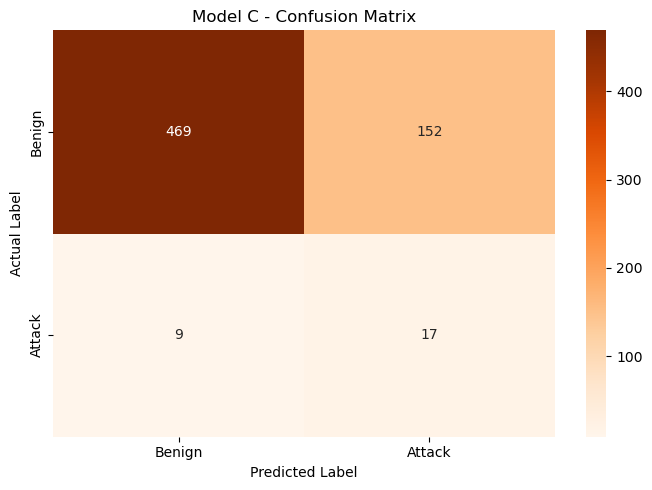

In [27]:

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_C,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Benign", "Attack"],
    yticklabels=["Benign", "Attack"]
)

plt.title("Model C - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()

plt.savefig(
    "PNG FOLDER/model_C_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
model_C_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    
    "Score": [
        accuracy_C,
        precision_C,
        recall_C,
        f1_C,
        roc_auc_C
    ]
})

model_C_results["Percentage"] = (
    model_C_results["Score"] * 100
)

model_C_results

,Metric,Score,Percentage
0,Accuracy,0.751159,75.115920
1,Precision,0.100592,10.059172
2,Recall,0.653846,65.384615
3,F1 Score,0.174359,17.435897
4,ROC-AUC,0.794996,79.499566


In [29]:
joblib.dump(
    model_C,
    "model_C.pkl"
)

print("Model C saved successfully as model_C.pkl")

Model C saved successfully as model_C.pkl


In [30]:
print("===================================")
print("          MODEL C SUMMARY")
print("===================================")

print("Total Dataset Rows :", len(df))
print("Model C Rows       :", len(df_C))
print("Training Rows      :", len(X_train_C))
print("Testing Rows       :", len(X_test_C))

print("\nURL Status:")
print("URL Available      :", df["url"].notna().sum())
print("URL Missing        :", df["url"].isna().sum())

print("\nURL Features:")
print("No URL features used")
print("Reason: URL is missing in all Model C records")

print("\nFeatures Used:")

for feature in X_C.columns:
    print("-", feature)

print("\nPerformance:")
print("Accuracy  :", round(accuracy_C * 100, 2), "%")
print("Precision :", round(precision_C * 100, 2), "%")
print("Recall    :", round(recall_C * 100, 2), "%")
print("F1 Score  :", round(f1_C * 100, 2), "%")
print("ROC-AUC   :", round(roc_auc_C * 100, 2), "%")

print("\nModel C completed successfully!")

          MODEL C SUMMARY
Total Dataset Rows : 10000
Model C Rows       : 3232
Training Rows      : 2585
Testing Rows       : 647

URL Status:
URL Available      : 6768
URL Missing        : 3232

URL Features:
No URL features used
Reason: URL is missing in all Model C records

Features Used:
- src_port
- dst_port
- protocol
- bytes_sent
- bytes_received
- user_agent
- is_internal_traffic
- hour
- day_of_week
- month

Performance:
Accuracy  : 75.12 %
Precision : 10.06 %
Recall    : 65.38 %
F1 Score  : 17.44 %
ROC-AUC   : 79.5 %

Model C completed successfully!
